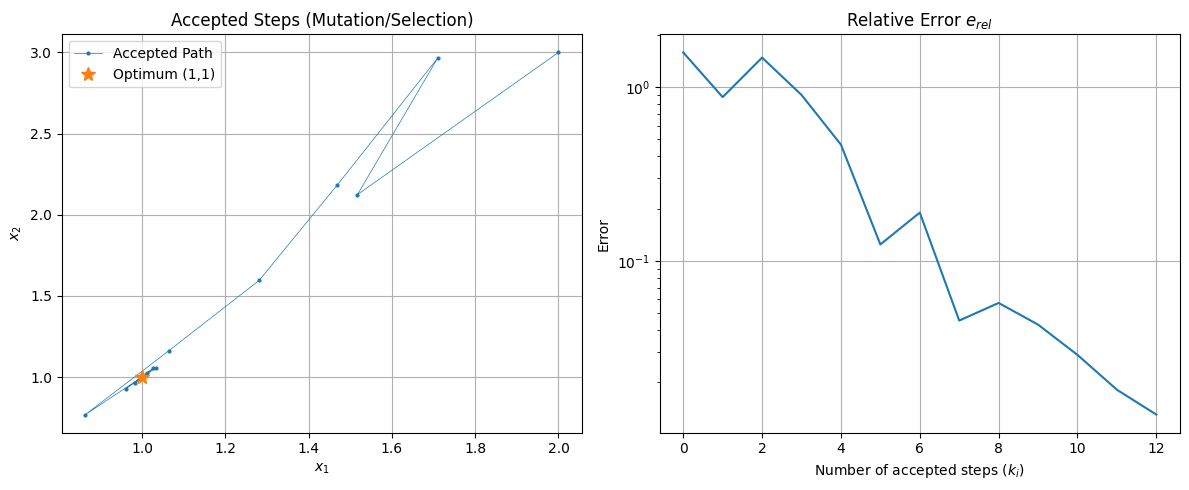

Final Result: [0.99150433 0.98361372]
Total Accepted Steps: 12
Final Relative Error: 0.013051560709456435
Accepted Step 0: Relative Error = 1.581139
Accepted Step 1: Relative Error = 0.875073
Accepted Step 2: Relative Error = 1.477050
Accepted Step 3: Relative Error = 0.900880
Accepted Step 4: Relative Error = 0.466334
Accepted Step 5: Relative Error = 0.124280
Accepted Step 6: Relative Error = 0.189571
Accepted Step 7: Relative Error = 0.045351
Accepted Step 8: Relative Error = 0.057282
Accepted Step 9: Relative Error = 0.042982
Accepted Step 10: Relative Error = 0.028774
Accepted Step 11: Relative Error = 0.018148
Accepted Step 12: Relative Error = 0.013052


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import rosen

def mutation_selection_rosenbrock():
    # Parameters 
    beta = 5e-3
    N = 5000
    x_0 = np.array([2.0, 3.0])
    x_opt = np.array([1.0, 1.0])
    
    x_k = x_0.copy()
    accepted_steps = [x_k.copy()]

    relative_errors = []
    initial_err = np.linalg.norm(x_0 - x_opt) / np.linalg.norm(x_opt)
    relative_errors.append(initial_err)

    for k in range(N + 1):
        delta_k = 1 / (1 + beta * k) 
        
        #  we pick a random angle phi
        phi = 2 * np.pi * np.random.rand()
        direction = np.array([np.cos(phi), np.sin(phi)])
        
        # new candidate point
        x_new = x_k + delta_k * direction
        
        # accept only if function value improves
        if rosen(x_new) < rosen(x_k):
            x_k = x_new
            accepted_steps.append(x_k.copy())
            
            # Calculate relative error e_rel(i)
            error = np.linalg.norm(x_k - x_opt) / np.linalg.norm(x_opt) # [cite: 60]
            relative_errors.append(error)
            
    return np.array(accepted_steps), np.array(relative_errors), x_k

steps, errors, final_x = mutation_selection_rosenbrock()

plt.figure(figsize=(12, 5))

# all accepted steps plot
plt.subplot(1, 2, 1)
plt.plot(steps[:, 0], steps[:, 1], '-o', markersize=2, linewidth=0.5, label='Accepted Path')
plt.plot(1, 1, '*', markersize=10, label='Optimum (1,1)')
plt.title("Accepted Steps (Mutation/Selection)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.grid(True)

# relative error plot
plt.subplot(1, 2, 2)
plt.plot(range(len(errors)), errors)
plt.yscale('log')
plt.title("Relative Error $e_{rel}$")
plt.xlabel("Number of accepted steps ($k_i$)")
plt.ylabel("Error")
plt.grid(True)

plt.tight_layout()
plt.show()

# Final Prints
print(f"Final Result: {final_x}")
print(f"Total Accepted Steps: {len(steps) - 1}")
print(f"Final Relative Error: {errors[-1]}")
for i, err in enumerate(errors):
    print(f"Accepted Step {i}: Relative Error = {err:.6f}")